# ISLR Python - Chapter 4, Applied Question 13

This notebook completes Applied Question 13 from Chapter 4 of *An Introduction to Statistical Learning with Applications in Python*. The analysis uses the `Weekly` data set to compare logistic regression, LDA, QDA, KNN, and naive Bayes for predicting market direction.

The notebook is written with standard Python packages (`pandas`, `statsmodels`, and `scikit-learn`). It tries to load `Weekly.csv` from the same folder first. If the file is not available locally, it downloads the data from the public ISLP GitHub repository.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)


In [2]:
# Load the Weekly data set.
# Option 1: local file in the same folder as this notebook.
# Option 2: public ISLP GitHub data URL.

local_path = Path("Weekly.csv")
url = "https://raw.githubusercontent.com/intro-stat-learning/ISLP/main/ISLP/data/Weekly.csv"

if local_path.exists():
    Weekly = pd.read_csv(local_path)
else:
    Weekly = pd.read_csv(url)

Weekly.head()


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


## (a) Numerical and Graphical Summaries

In [3]:
# Basic numerical summaries
display(Weekly.info())
display(Weekly.describe())
display(Weekly["Direction"].value_counts())

# Correlation among numeric variables
display(Weekly.select_dtypes(include="number").corr())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


None

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,2000.048669,0.150585,0.151079,0.147205,0.145818,0.139893,1.574618,0.149899
std,6.033182,2.357013,2.357254,2.360502,2.360279,2.361285,1.686636,2.356927
min,1990.000000,-18.195000,-18.195000,-18.195000,-18.195000,-18.195000,0.087465,-18.195000
25%,1995.000000,-1.154000,-1.154000,-1.158000,-1.158000,-1.166000,0.332022,-1.154000
50%,2000.000000,0.241000,0.241000,0.241000,0.238000,0.234000,1.002680,0.241000
75%,2005.000000,1.405000,1.409000,1.409000,1.409000,1.405000,2.053727,1.405000
max,2010.000000,12.026000,12.026000,12.026000,12.026000,12.026000,9.328214,12.026000


Direction
Up      605
Down    484
Name: count, dtype: int64

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000


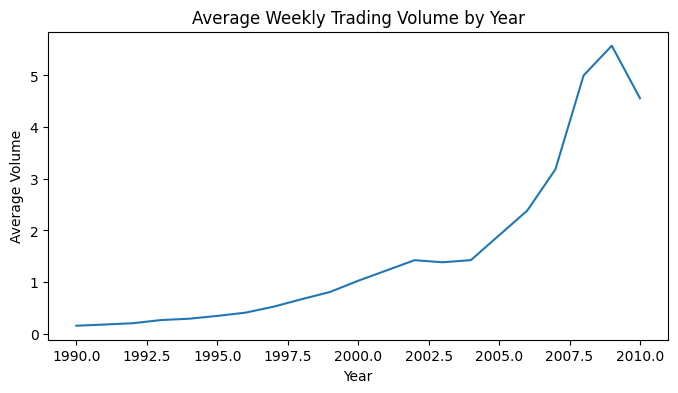

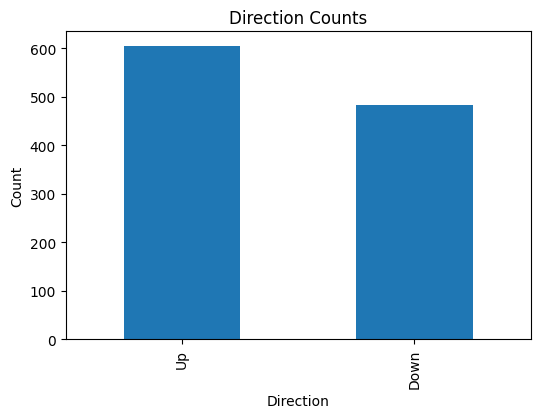

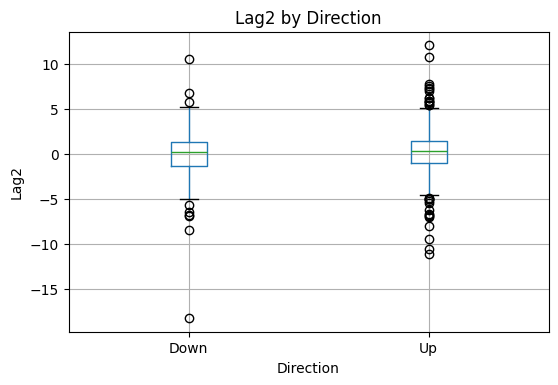

In [4]:
# Graphical summaries

fig, ax = plt.subplots(figsize=(8, 4))
Weekly.groupby("Year")["Volume"].mean().plot(ax=ax)
ax.set_title("Average Weekly Trading Volume by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average Volume")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
Weekly["Direction"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Direction Counts")
ax.set_xlabel("Direction")
ax.set_ylabel("Count")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
Weekly.boxplot(column="Lag2", by="Direction", ax=ax)
ax.set_title("Lag2 by Direction")
ax.set_xlabel("Direction")
ax.set_ylabel("Lag2")
plt.suptitle("")
plt.show()


## (a) Numerical and Graphical Summary

The data contain 1,089 weekly observations from 1990 through 2010. The response variable `Direction` has more `Up` weeks than `Down` weeks. The correlation matrix usually shows that `Volume` has a strong relationship with `Year`, reflecting an increasing trading volume trend over time. The lag variables have weak correlations with the response-related variable `Today`, so the graphical and numerical summaries do not show a strong obvious predictive pattern from the lag variables alone.


## (b) Logistic Regression on the Full Data Set

In [5]:
# (b) Logistic regression on the full data set

predictors = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]
Weekly["Direction01"] = (Weekly["Direction"] == "Up").astype(int)

X_full = sm.add_constant(Weekly[predictors])
y_full = Weekly["Direction01"]

logit_full = sm.GLM(y_full, X_full, family=sm.families.Binomial()).fit()
print(logit_full.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:            Direction01   No. Observations:                 1089
Model:                            GLM   Df Residuals:                     1082
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -743.18
Date:                Fri, 08 May 2026   Deviance:                       1486.4
Time:                        03:34:24   Pearson chi2:                 1.09e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.009000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.0

## (c) Confusion Matrix for Full-Data Logistic Regression

In [6]:
# (c) Confusion matrix and overall fraction correct for full-data logistic regression

def confusion_df(y_true, y_pred, labels=("Down", "Up")):
    return pd.DataFrame(
        confusion_matrix(y_true, y_pred, labels=list(labels)),
        index=pd.Index(labels, name="Truth"),
        columns=pd.Index(labels, name="Predicted")
    )

probs_full = logit_full.predict(X_full)
pred_full = np.where(probs_full > 0.5, "Up", "Down")

cm_full = confusion_df(Weekly["Direction"], pred_full)
acc_full = accuracy_score(Weekly["Direction"], pred_full)

display(cm_full)
print(f"Overall fraction correct: {acc_full:.4f}")
print(f"Overall error rate: {1 - acc_full:.4f}")


Predicted,Down,Up
Truth,,
Down,54,430
Up,48,557


Overall fraction correct: 0.5611
Overall error rate: 0.4389


## (d)-(h) Model Comparison on 2009-2010 Holdout Data

In [7]:
# Train on 1990-2008 and test on 2009-2010.
# Use Lag2 as the only predictor for parts (d)-(h).

train = Weekly["Year"] <= 2008
test = Weekly["Year"] >= 2009

X_train = Weekly.loc[train, ["Lag2"]]
X_test = Weekly.loc[test, ["Lag2"]]
y_train = Weekly.loc[train, "Direction"]
y_test = Weekly.loc[test, "Direction"]
y_train01 = (y_train == "Up").astype(int)

results = []

def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_df(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    err = 1 - acc
    results.append({"Method": model_name, "Accuracy": acc, "Error Rate": err})
    print(f"\n{model_name}")
    display(cm)
    print(f"Accuracy: {acc:.4f}")
    print(f"Error Rate: {err:.4f}")

# (d) Logistic regression
logit_lag2 = sm.GLM(y_train01, sm.add_constant(X_train), family=sm.families.Binomial()).fit()
prob_logit = logit_lag2.predict(sm.add_constant(X_test))
pred_logit = np.where(prob_logit > 0.5, "Up", "Down")
evaluate_model("Logistic Regression, Lag2", y_test, pred_logit)

# (e) LDA
lda_model = LDA().fit(X_train, y_train)
pred_lda = lda_model.predict(X_test)
evaluate_model("LDA, Lag2", y_test, pred_lda)

# (f) QDA
qda_model = QDA().fit(X_train, y_train)
pred_qda = qda_model.predict(X_test)
evaluate_model("QDA, Lag2", y_test, pred_qda)

# (g) KNN with K = 1
knn1_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)).fit(X_train, y_train)
pred_knn1 = knn1_model.predict(X_test)
evaluate_model("KNN, K=1, Lag2", y_test, pred_knn1)

# (h) Naive Bayes
nb_model = GaussianNB().fit(X_train, y_train)
pred_nb = nb_model.predict(X_test)
evaluate_model("Naive Bayes, Lag2", y_test, pred_nb)

summary_results = pd.DataFrame(results)
display(summary_results)



Logistic Regression, Lag2


Predicted,Down,Up
Truth,,
Down,9,34
Up,5,56


Accuracy: 0.6250
Error Rate: 0.3750

LDA, Lag2


Predicted,Down,Up
Truth,,
Down,9,34
Up,5,56


Accuracy: 0.6250
Error Rate: 0.3750

QDA, Lag2


...

Predicted,Down,Up
Truth,,
Down,22,21
Up,32,29


Accuracy: 0.4904
Error Rate: 0.5096

Naive Bayes, Lag2


Predicted,Down,Up
Truth,,
Down,0,43
Up,0,61


Accuracy: 0.5865
Error Rate: 0.4135


,Method,Accuracy,Error Rate
0,"Logistic Regression, Lag2",0.625000,0.375000
1,"LDA, Lag2",0.625000,0.375000
2,"QDA, Lag2",0.586538,0.413462
3,"KNN, K=1, Lag2",0.490385,0.509615
4,"Naive Bayes, Lag2",0.586538,0.413462


## (i) Best Method from Parts (d)-(h)

Using `Lag2` as the only predictor and testing on the 2009-2010 holdout period, logistic regression and LDA provide the best results among the required methods. Both correctly classify 62.5% of the held-out observations, while QDA and naive Bayes classify 58.7% correctly and KNN with K = 1 classifies 49.0% correctly.


## (j) Additional Experiments

In [8]:
# (j) Experiment with predictor combinations, transformations, interactions, and K values.

base_predictors = ["Lag1", "Lag2", "Lag3", "Lag4", "Lag5", "Volume"]
labels = ("Down", "Up")
experiment_rows = []

def score_prediction(method, features, y_pred, K=None):
    cm = confusion_df(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    experiment_rows.append({
        "Method": method,
        "Features": features,
        "K": K,
        "Accuracy": acc,
        "Error Rate": 1 - acc,
        "Confusion Matrix": cm
    })

# Standard predictor subsets: single predictors, pairs, triples, and all predictors.
feature_sets = []
for r in range(1, 4):
    for combo in combinations(base_predictors, r):
        feature_sets.append((list(combo), " + ".join(combo)))
feature_sets.append((base_predictors, "Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume"))

# Custom transformation / interaction feature sets.
custom_feature_builders = [
    ("Lag2 + Lag2^2", lambda df: pd.DataFrame({"Lag2": df["Lag2"], "Lag2_sq": df["Lag2"] ** 2}, index=df.index)),
    ("Lag1 + Lag2 + Lag1:Lag2", lambda df: pd.DataFrame({
        "Lag1": df["Lag1"],
        "Lag2": df["Lag2"],
        "Lag1_Lag2": df["Lag1"] * df["Lag2"]
    }, index=df.index)),
    ("Lag1 + Lag2 + Lag2^2 + Lag1:Lag2", lambda df: pd.DataFrame({
        "Lag1": df["Lag1"],
        "Lag2": df["Lag2"],
        "Lag2_sq": df["Lag2"] ** 2,
        "Lag1_Lag2": df["Lag1"] * df["Lag2"]
    }, index=df.index)),
]

def run_models_on_features(Xtr, Xte, feature_name):
    # Logistic regression
    try:
        model = sm.GLM((y_train == "Up").astype(int), sm.add_constant(Xtr), family=sm.families.Binomial()).fit()
        pred = np.where(model.predict(sm.add_constant(Xte)) > 0.5, "Up", "Down")
        score_prediction("Logistic Regression", feature_name, pred)
    except Exception as e:
        pass

    # LDA
    try:
        pred = LDA().fit(Xtr, y_train).predict(Xte)
        score_prediction("LDA", feature_name, pred)
    except Exception as e:
        pass

    # QDA
    try:
        pred = QDA().fit(Xtr, y_train).predict(Xte)
        score_prediction("QDA", feature_name, pred)
    except Exception as e:
        pass

    # Naive Bayes
    try:
        pred = GaussianNB().fit(Xtr, y_train).predict(Xte)
        score_prediction("Naive Bayes", feature_name, pred)
    except Exception as e:
        pass

    # KNN with different K values
    for K in [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]:
        try:
            pred = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=K)).fit(Xtr, y_train).predict(Xte)
            score_prediction("KNN", feature_name, pred, K=K)
        except Exception as e:
            pass

for cols, feature_name in feature_sets:
    Xtr = Weekly.loc[train, cols]
    Xte = Weekly.loc[test, cols]
    run_models_on_features(Xtr, Xte, feature_name)

for feature_name, builder in custom_feature_builders:
    Xtr = builder(Weekly.loc[train])
    Xte = builder(Weekly.loc[test])
    run_models_on_features(Xtr, Xte, feature_name)

experiment_summary = (
    pd.DataFrame([{k: v for k, v in row.items() if k != "Confusion Matrix"} for row in experiment_rows])
    .sort_values(["Accuracy", "Method"], ascending=[False, True])
    .reset_index(drop=True)
)

display(experiment_summary.head(20))

best_row = max(experiment_rows, key=lambda row: row["Accuracy"])
print("Best model found:")
print({k: v for k, v in best_row.items() if k != "Confusion Matrix"})
display(best_row["Confusion Matrix"])


,Method,Features,K,Accuracy,Error Rate
0,KNN,Lag1 + Lag2 + Lag3,21.0,0.634615,0.365385
1,KNN,Lag3 + Lag4 + Lag5,3.0,0.625000,0.375000
2,LDA,Lag2,NaN,0.625000,0.375000
3,LDA,Lag2 + Lag3,NaN,0.625000,0.375000
4,LDA,Lag2 + Lag4,NaN,0.625000,0.375000
5,Logistic Regression,Lag2,NaN,0.625000,0.375000
6,Logistic Regression,Lag2 + Lag3,NaN,0.625000,0.375000
7,Logistic Regression,Lag2 + Lag4,NaN,0.625000,0.375000
8,Logistic Regression,Lag2 + Lag2^2,NaN,0.625000,0.375000
9,QDA,Lag2 + Lag2^2,NaN,0.625000,0.375000


Best model found:
{'Method': 'KNN', 'Features': 'Lag1 + Lag2 + Lag3', 'K': 21, 'Accuracy': 0.6346153846153846, 'Error Rate': 0.3653846153846154}


Predicted,Down,Up
Truth,,
Down,25,18
Up,20,41
